# Barcelona Noise Prediction: OSM Land Use Feature Engineering
This notebook processes the OSM land use geopackage to extract percentages of commercial, residential, industrial, green, and other areas within 50m and 100m buffers of our street network.

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import os

## Import roads

In [2]:
osm_roads = gpd.read_file("data/bcn_osmnx_edges.gpkg")
print(osm_roads.crs)  #CRS = Coordinate Reference System
print(osm_roads.shape)
print(osm_roads.columns.tolist())
print("Number of street segments:", len(osm_roads))

EPSG:25831
(16541, 21)
['u', 'v', 'key', 'osmid', 'highway', 'lanes', 'maxspeed', 'name', 'oneway', 'reversed', 'length', 'access', 'junction', 'ref', 'width', 'est_width', 'tunnel', 'bridge', 'service', 'segment_id', 'geometry']
Number of street segments: 16541


## Import land use

In [3]:
osm_landuse = gpd.read_file("../../layers/bcn_gis_osm_landuse.gpkg")
print("OSM Landuse CRS:", osm_landuse.crs)
print("Number of land use polygons:", len(osm_landuse))

# Ensure CRSs match
if osm_landuse.crs != osm_roads.crs:
    print("Aligning CRS...")
    osm_landuse = osm_landuse.to_crs(osm_roads.crs)

display(osm_landuse.head(2))

OSM Landuse CRS: EPSG:25831
Number of land use polygons: 4676


,osm_id,code,fclass,name,geometry
0,7996266,7202,park,Jardins del Palau de Pedralbes,"MULTIPOLYGON (((426059.127 4582204.941, 426063..."
1,10068992,7202,park,Plaça del Nord,"MULTIPOLYGON (((429381.853 4584285.289, 429405..."


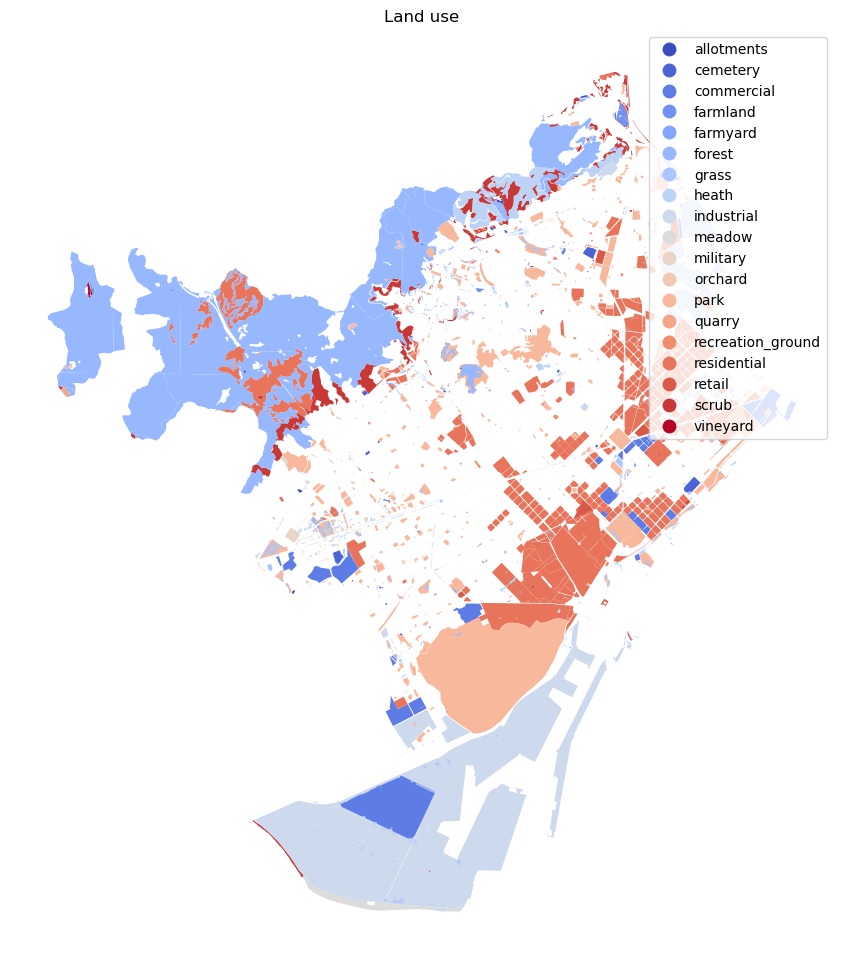

In [4]:
ax = osm_landuse.plot(cmap="coolwarm", column='fclass', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Land use')
ax.set_axis_off()

## Get the green areas

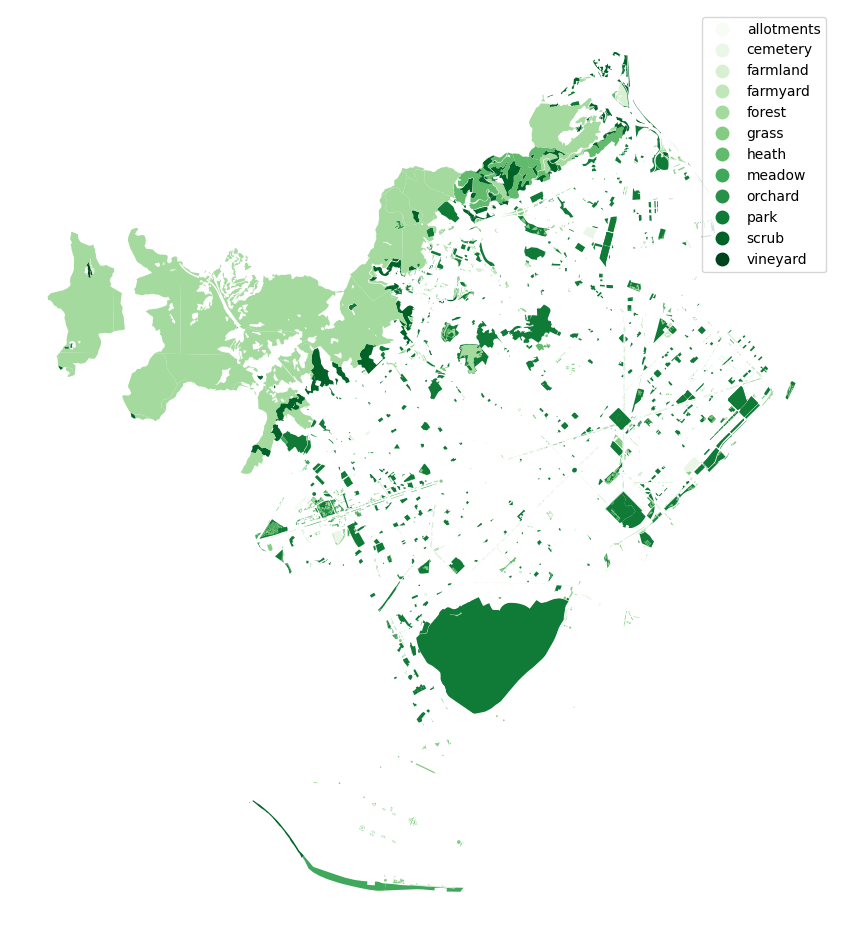

In [5]:
green_categories = ['forest', 'grass', 'meadow', 'orchard', 'vineyard', 'farmland', 'farmyard', 'park','heath', 'scrub', 'meadow', 'orchard', 'allotments', 'cemetery']  
green_land = osm_landuse[osm_landuse['fclass'].isin(green_categories)]

ax = green_land.plot(cmap="Greens", column='fclass', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_axis_off()

## Calculate green percentage in 50 m buffer

In [6]:

# 1. Buffer the streets
osm_roads['buffer'] = osm_roads.geometry.buffer(50)  # adjust buffer size as needed

# 2. Calculate percentage of buffer covered by green
def calc_green_coverage(buffer_geom, green_gdf):
    # Get all green polygons that intersect the buffer
    intersecting = green_gdf[green_gdf.intersects(buffer_geom)]
    if intersecting.empty:
        return 0
    # Union all green polygons first to avoid double-counting overlapping areas
    green_union = intersecting.union_all()
    intersection_area = green_union.intersection(buffer_geom).area
    # Calculate percentage
    return (intersection_area / buffer_geom.area) * 100 if buffer_geom.area > 0 else 0

osm_roads['green_pct'] = osm_roads['buffer'].apply(lambda buf: calc_green_coverage(buf, green_land))


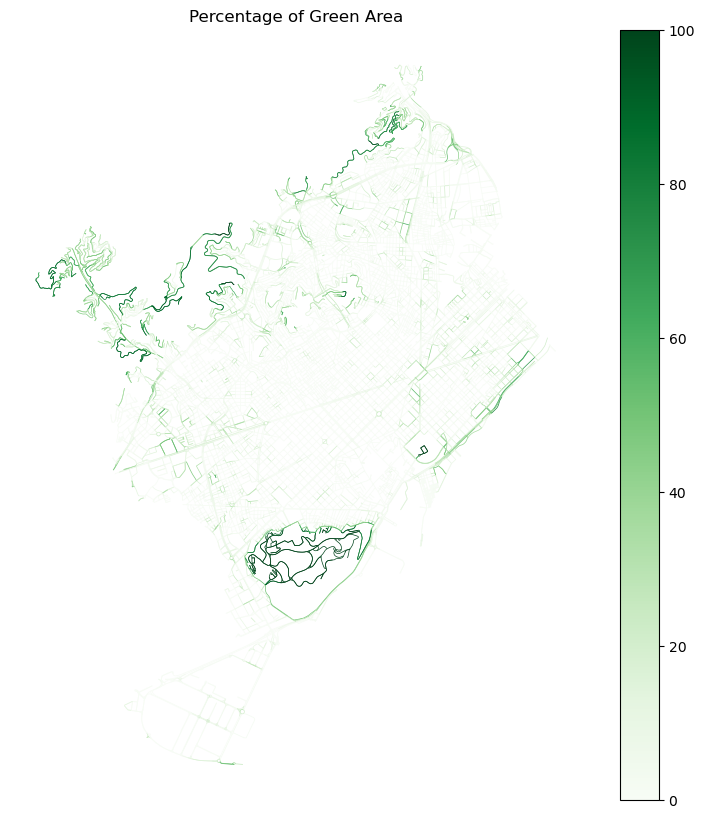

In [7]:
ax = osm_roads.plot(column='green_pct', cmap='Greens', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Percentage of Green Area')
ax.set_axis_off()

In [8]:
commercial_land = osm_landuse[osm_landuse['fclass'] == 'commercial']

def calc_commercial_coverage(buffer_geom, commercial_gdf):
    intersecting = commercial_gdf[commercial_gdf.intersects(buffer_geom)]
    if intersecting.empty:
        return 0
    # Union all polygons first to avoid double-counting overlapping areas
    commercial_union = intersecting.union_all()
    intersection_area = commercial_union.intersection(buffer_geom).area
    return (intersection_area / buffer_geom.area) * 100 if buffer_geom.area > 0 else 0

osm_roads['commercial_pct'] = osm_roads['buffer'].apply(lambda buf: calc_commercial_coverage(buf, commercial_land))


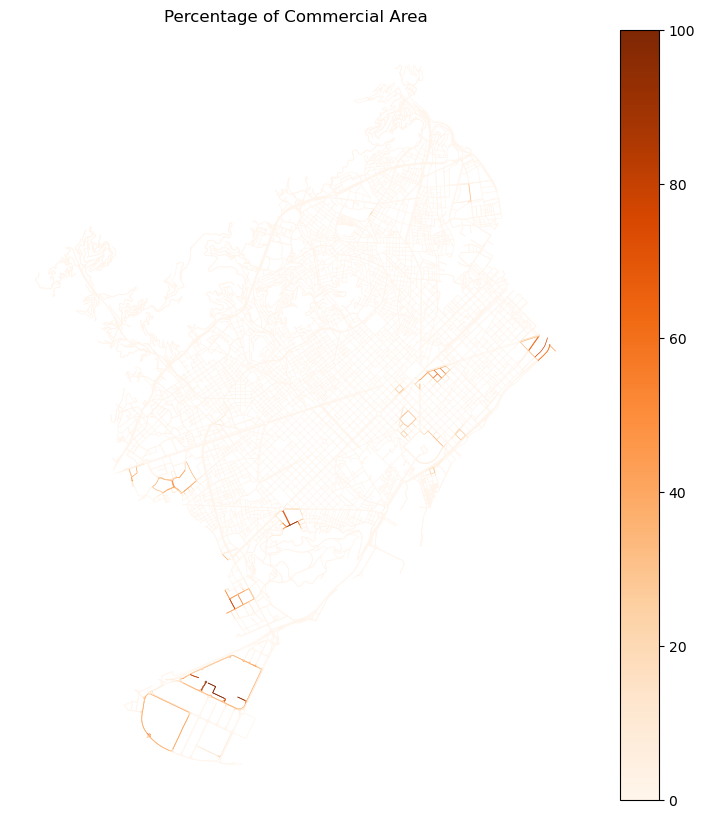

In [9]:
ax = osm_roads.plot(column='commercial_pct', cmap='Oranges', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Percentage of Commercial Area')
ax.set_axis_off()

In [10]:
industrial_land = osm_landuse[osm_landuse['fclass'] == 'industrial']

def calc_industrial_coverage(buffer_geom, industrial_gdf):
    intersecting = industrial_gdf[industrial_gdf.intersects(buffer_geom)]
    if intersecting.empty:
        return 0
    # Union all polygons first to avoid double-counting overlapping areas
    industrial_union = intersecting.union_all()
    intersection_area = industrial_union.intersection(buffer_geom).area
    return (intersection_area / buffer_geom.area) * 100 if buffer_geom.area > 0 else 0

osm_roads['industrial_pct'] = osm_roads['buffer'].apply(lambda buf: calc_industrial_coverage(buf, industrial_land))

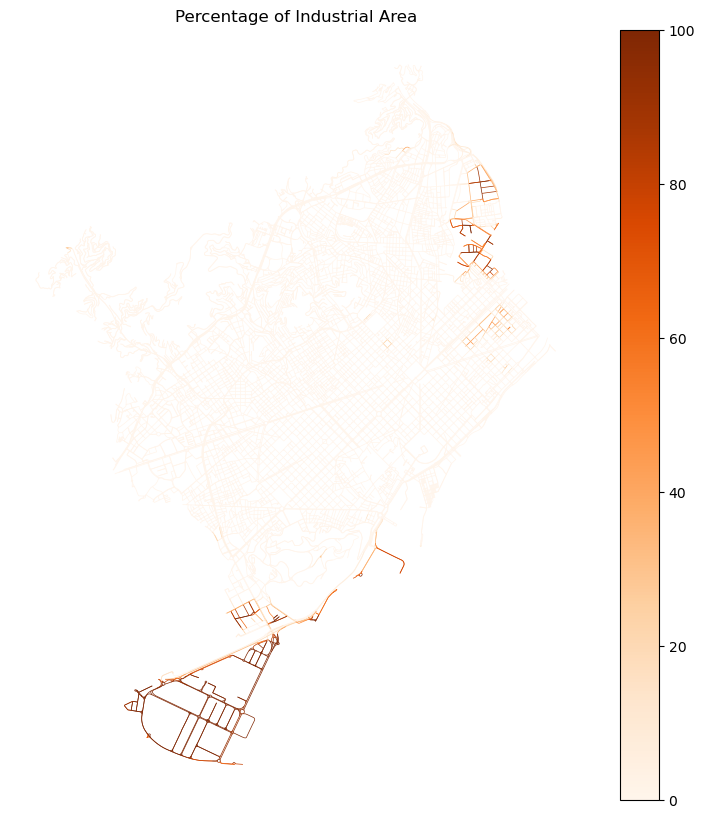

In [11]:
ax = osm_roads.plot(column='industrial_pct', cmap='Oranges', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Percentage of Industrial Area')
ax.set_axis_off()

## Merge and Export

In [12]:
dataset = pd.DataFrame({
    "road_id": osm_roads['segment_id'],
    "green": osm_roads['green_pct'],
    "industrial": osm_roads['industrial_pct'],
    "commercial": osm_roads['commercial_pct']
})

dataset = dataset.fillna(0)
display(dataset.head(5))

# Export the dataset to CSV 
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "osm_landuse_features.csv"), index=False)
print("Exported osm_landuse_features.csv")

,road_id,green,industrial,commercial
0,21638845_885308258_0,9.169742,0.0,0.0
1,21638845_13175411896_0,1.024610,0.0,0.0
2,21638865_30343650_0,0.000000,0.0,0.0
3,21638867_1636238503_0,0.000000,0.0,0.0
4,21638867_1403082237_0,0.000000,0.0,0.0


Exported osm_landuse_features.csv
